# How to Represent Part-Whole Hierarchies in a Neural Network — Summary

# https://arxiv.org/pdf/2102.12627

## Abstract
This paper does not describe a working system. Instead, it presents a single representational idea—using "islands" of nearly identical embedding vectors to represent nodes in an image's part-whole parse tree—and explores its implications through an imagined architecture called GLOM. GLOM combines ideas from transformers, neural fields, contrastive representation learning, distillation, and capsule networks to address how a neural network with fixed architecture can parse each image into a different, image-specific part-whole hierarchy.

## Problems
- A real neural network cannot dynamically allocate a discrete group of neurons to represent an arbitrary node in a parse tree, since neuron function is determined by fixed incoming/outgoing weights that cannot be rapidly reassigned.
- Prior capsule models (Sabour et al., 2017; Hinton et al., 2018; Kosiorek et al., 2019) solve this by pre-allocating a capsule to each possible type of part in each region of the image, but this forces a hard, mixture-model-style decision about whether two visually similar parts (e.g., a car headlight and an eye) are the "same" type, preventing effective sharing of knowledge between similar parts.
- Capsule models have not scaled well to larger datasets, lacking the "just works" character of ideas like stochastic gradient descent or transformers.
- Using universal (identical, type-agnostic) capsules avoids the mixture problem but introduces a symmetry-breaking issue in deciding which universal object-level capsule a given part should be routed to.
- Standard neural representations struggle to combine multiple uncertain sources of information (bottom-up, top-down, lateral) about pose and identity in a principled, probabilistic way.
- Contrastive learning approaches that enforce similarity between whole-image crops are inappropriate for object-level recognition, since two crops of the same image may contain different, only partially overlapping sets of objects.

## Proposed Solutions
- Represent each parse-tree node as an island of nearly identical embedding vectors shared across all image locations belonging to that node, eliminating the need for dynamic neuron allocation or pre-assigned type-specific capsules.
- Assign a "universal" capsule to every location at every level (scene, object, part, sub-part), rather than routing parts to a discrete set of type-specific capsules — avoiding both symmetry breaking and dynamic routing.
- Update each location's embedding at each level, at each time step, as a combination of four contributions:
  1. A bottom-up prediction from the level below (previous time step).
  2. A top-down prediction from the level above (previous time step).
  3. The embedding's own previous value.
  4. An attention-weighted average of same-level embeddings at nearby locations, computed as:
$$w_{xy} = \frac{e^{\beta L_x \cdot L_y}}{\sum_z e^{\beta L_x \cdot L_z}}$$
- Train the entire system end-to-end to reconstruct images with missing regions (a denoising-autoencoder objective), combined with contrastive regularizers that encourage islands of near-identical embeddings by rewarding agreement between the new embedding at a level and its bottom-up/top-down predictions.
- Represent part-whole coordinate transforms not via explicit matrices/quaternions (as in prior capsule models) but by entangling pose, identity, deformation, and texture within a single learned, high-dimensional embedding, letting a multi-layer neural net condition its transformation on the part-identity vector itself.
- Represent uncertainty using populations of neurons tuned to (possibly non-Gaussian, e.g., Gaussian-plus-uniform "unibump") distributions over an underlying latent space, so that multiple information sources can contribute probability distributions combined via (weighted) products/geometric means rather than only point estimates.

## Purpose
The paper aims to answer how a neural network with a fixed architecture can produce a different part-whole parse for every image, by proposing a unifying representational principle (islands of identity) that integrates recent advances (transformers, neural fields, contrastive learning, distillation, capsules) into a single coherent, if hypothetical, framework — intended to improve the interpretability of transformer-like vision/language systems and to serve as a design document and discussion vehicle rather than a validated implementation.

## Methodology
| Component | Description |
|---|---|
| Architecture | A large number of identical-weight "columns," each a stack of ~5 spatially local, level-specific autoencoders (bottom-up encoder + top-down decoder) representing a fixed-depth part-whole hierarchy (e.g., scene → object → part → sub-part → lowest level) |
| Embedding update | At each location and level, weighted combination of bottom-up prediction, top-down prediction, previous embedding, and attention-weighted same-level neighbor average (Eq. 1) |
| Training objective | End-to-end reconstruction of images with missing regions (denoising autoencoding), plus regularizers encouraging bottom-up/top-down predictions to agree with a consensus (weighted geometric mean of all four update sources) |
| Representation of uncertainty | Populations of neurons with (Gaussian or Gaussian+uniform) tuning curves over an underlying latent pose/identity space, allowing additive combination of log-probability contributions from multiple sources |
| Relation to transformers | GLOM is reframed as a transformer with tied weights across "layers" (time steps), query=key=value=embedding, and attention heads repurposed to represent hierarchy levels rather than providing extra expressive capacity |
| Relation to CNNs | GLOM is described as a special CNN using only 1×1 convolutions (except the front end), parameter-free averaging for cross-location interaction, iterative top-down settling via neural fields, and built-in contrastive/hierarchical segmentation rather than separate bounding-box detection |
| Biological plausibility discussion | Proposes knowledge distillation/co-distillation across columns (rather than literal weight sharing) to address concerns about synaptic weight replication, and speculates about a role for sleep (offline negative-example generation) in preventing representational collapse during contrastive learning |

Note: No empirical implementation, dataset, or quantitative evaluation is presented; the paper is explicitly speculative and conceptual (a "thought experiment"), with the author stating a companion empirical project (testing generalization to novel viewpoints) is underway separately.

## Results
As the paper self-identifies, it does not describe or evaluate a working system, so there are no quantitative results, benchmarks, or ablations. Instead, the paper's "results" consist of conceptual arguments and comparisons:
- GLOM is argued to overcome the main disadvantage of capsule models (pre-allocation of neurons to discrete part/object types) by allowing continuous, distributed representation of part identity, enabling greater knowledge sharing (e.g., between arms and legs) and flexible numbers/types of parts per object.
- GLOM is argued to avoid dynamic routing altogether, since every location constructs its own vector representation of the whole it belongs to, with uncertainty represented as blends of embedding vectors rather than routing coefficients.
- The island-formation clustering process is argued to be superior to EM-style capsule routing because splitting and merging of clusters happens automatically and continuously, without needing to pre-specify or discretely adjust the number of clusters.
- A biological plausibility analysis suggests that co-distillation (rather than literal weight sharing) could allow location-specific bottom-up/top-down networks to converge toward functionally similar computations while tolerating different input structures (e.g., varying receptive field sizes with retinal eccentricity), and offers a statistical argument reconciling the discrepancy between the number of synapses (~$$10^{13}$$) and the number of fixations experienced in early life (~$$10^{9}$$) by distributing learning across ~$$10^4$$ columns.
- The paper draws formal analogies between GLOM and 2-D Ising models (replacing binary spins with high-dimensional real vectors and adding multiple interacting levels), and between the ISA (inheritance) hierarchy and the part-whole hierarchy, arguing both can be encoded in different subsections of the same embedding vector.

## Conclusions
The paper concludes that representing parse-tree nodes as islands of nearly identical, continuous embedding vectors—rather than via discrete capsule allocation or symbolic pointer structures—offers a promising, unifying way to reconcile classical Gestalt (field-based) and classical AI (structural-description-based) theories of perception within a single neural architecture. This approach is argued to preserve capsule models' key strengths (viewpoint-equivariant activities with viewpoint-invariant weights, coincidence-based recognition, and no dynamic neuron allocation) while eliminating their principal weakness (discrete, pre-allocated part/object types). The author explicitly frames GLOM as an untested set of interconnected ideas rather than a validated system, acknowledges serious credibility concerns stemming from the absence of an implementation, and identifies empirical testing of viewpoint generalization as ongoing future work, while inviting other research groups to evaluate the proposed ideas.

# Mathematical and Statistical Content Summary

## 1. Attention Weighting Formula (Equation 1)
$$w_{xy} = \frac{e^{\beta L_x \cdot L_y}}{\sum_z e^{\beta L_x \cdot L_z}}$$

- $$L_x, L_y$$: embedding vectors at level $$L$$ for locations $$x$$ and $$y$$.
- $$L_x \cdot L_y$$: scalar (dot) product measuring similarity between two embeddings.
- $$\beta$$: an "inverse temperature" parameter controlling the sharpness of attention.
- $$z$$: indexes all locations that $$x$$ attends to at level $$L$$.

**Role:** This is a standard softmax-based attention formula, used here so that a location's embedding at a level is updated by an attention-weighted average of nearby locations' embeddings at the same level. Higher similarity (larger dot product) yields greater attention weight, implementing the "islands of identity" mechanism: locations with similar embeddings reinforce each other, encouraging clusters (islands) to form. Increasing $$\beta$$ over time is suggested to sharpen this clustering as the network "settles" on an interpretation.

## 2. Weighted Combination of Four Update Sources
The embedding at level $$L$$, location $$x$$, at each time step is described (in words, not as an explicit equation) as a weighted average of:
1. Bottom-up prediction (from level $$L-1$$, previous time step).
2. Top-down prediction (from level $$L+1$$, previous time step).
3. The embedding's own previous value.
4. The attention-weighted average from Eq. 1 (same-level, nearby locations).

**Role:** This defines the core recurrent update rule of the GLOM architecture. It is conceptually a weighted geometric mean of several probability distributions (see below) rather than a simple additive update, reflecting the idea that these sources are treated as partially dependent estimates that should be combined multiplicatively (as distributions) rather than independently.

## 3. Weighted Geometric Mean as a Combination Rule
The paper states that the "consensus opinion" combining bottom-up, top-down, previous state, and lateral contributions should be computed as a weighted geometric mean of the predicted distributions, not a simple product (which would assume independence) or arithmetic mean.

**Role:** This reflects a statistical principle: when combining multiple correlated (non-independent) estimates of the same quantity, a weighted geometric mean avoids the overconfidence that would result from treating dependent sources as independent (as a plain product of distributions would). This underlies the regularizer used to encourage island formation.

## 4. Kolmogorov–Arnold Superposition Theorem
Stated informally: every multivariate continuous function can be represented as a superposition (sum) of continuous functions of one variable each. Example given: multiplication as $$\exp(\log a + \log b)$$.

**Role:** Used as a mathematical analogy motivating GLOM's design choice that simple averaging/summation across locations (rather than more complex interactions) might suffice to combine information, provided the right per-location encoding functions are learned — paralleling the encoder/decoder structure of the architecture. The paper notes the theorem's constructive form is impractical, so it serves only as conceptual motivation, not a literal algorithm.

## 5. Gaussian Tuning Curves and Log-Probability Representation of Uncertainty
A population of $$N \gg M$$ neurons, each tuned to a Gaussian in an $$M$$-dimensional latent space, is proposed. Taking logs turns each neuron's tuning curve into a parabolic bump in log-probability space. Neural activity scales the height of its bump, and bumps are summed:
$$\log(\text{unnormalized Gaussian}) = \sum_i (\text{activity}_i \times \text{parabolic bump}_i)$$

**Role:** Demonstrates, in a simplified form, how a population of neurons can represent a full (unnormalized) Gaussian probability distribution over a latent pose/identity space, and how independent sources of evidence can be combined simply by summing their contributions to the same neurons (equivalent to multiplying the underlying Gaussians). This underlies the paper's argument for why neural populations can represent and combine uncertain information about pose without a single neuron needing to represent a single physical variable directly.

## 6. Mixture of Gaussian and Uniform ("Unibump") Distributions
Described qualitatively: replacing a pure Gaussian tuning curve with a mixture of a Gaussian and a uniform distribution produces a "unibump" — a log-probability bump with zero gradient (flat sides) far from its peak, rather than the quadratically increasing penalty of a pure Gaussian (parabolic) bump.

**Role:** Explains how neural populations could represent multi-modal probability distributions (e.g., a diagonal line being consistent with either a tilted square or an upright diamond) by summing several localized unibumps — a mixture model concept used to argue that neural tuning curves need not be globally quadratic to support flexible uncertainty representation.

## 7. Analogy to 2-D Ising Models
The paper compares GLOM's island-formation dynamics to a 2-D Ising model, where a grid of binary spins settles into a configuration minimizing an energy function that rewards agreement between neighboring spins, generalized by:
1. Replacing binary spins with high-dimensional real-valued vectors.
2. Using multiple interacting fields (one per hierarchy level) instead of a single field, with complex (neural-net-computed) rather than simple weight-matrix interactions between adjacent levels.

**Role:** Provides a statistical-physics analogy for the "island formation" (clustering) dynamics of GLOM — locations' embeddings behave like spins that settle toward local agreement, but in a richer, continuous, multi-level setting. This is descriptive/interpretive rather than a proposed computational method.

## 8. Statistical Argument on Synapse-to-Fixation Ratio
A back-of-envelope calculation: the human visual system has roughly $$10^{13}$$ synapses, while a person experiences roughly $$10^9$$ fixations in their first ten years. Splitting the visual system into $$\sim 10^4$$ columns implies each column's bottom-up/top-down networks have only about $$10^9$$ synapses, while the effective number of training examples pooled across the $$10^4$$-column ensemble (via distillation) is about $$10^{13}$$.

**Role:** A rough statistical/order-of-magnitude estimate used to argue that GLOM's proposed weight-sharing-via-distillation across columns resolves an apparent overfitting concern (far more synapses than training examples in a single column) by effectively pooling training signal across many structurally-shared columns — an informal capacity/data-efficiency argument rather than a formal statistical proof.

## 9. Contrastive Learning Objective (Described Conceptually)
Contrastive learning is described as maximizing agreement between representations that should match (positive pairs) while maintaining separation between representations that should not match (negative pairs), historically implemented via losses that pull matching representations together and push non-matching ones apart, but noted to risk representational collapse (all embeddings shrinking to be trivially similar) without proper negative examples or normalization.

**Role:** Frames the regularization needed to prevent trivial/collapsed solutions when training embeddings to form islands of agreement — motivating GLOM's proposed alternative (letting each location choose which other locations to resemble, forming islands, rather than requiring global similarity/dissimilarity across fixed crops).

## Summary of Mathematical Contribution
This paper is predominantly conceptual and contains very little formal mathematics — the only explicit equation is the softmax attention-weighting formula (Eq. 1). The remaining mathematical content consists of qualitative statistical reasoning and analogies: geometric-mean combination of distributions, population-coded Gaussian/unibump representations of uncertainty in log-probability space, the Kolmogorov–Arnold theorem as a motivating analogy, a 2-D Ising model analogy for island formation, and an informal synapse-count argument for biological plausibility. None of these are developed into a full derivation, proof, or trained model; they serve as illustrative or motivating devices supporting the paper's central representational proposal rather than as a rigorous mathematical framework.

# Research Gaps and Proposed Solutions

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | A real neural network cannot dynamically allocate a group of neurons to represent an arbitrary node in a parse tree, since neuron function is fixed by its incoming/outgoing weights, which cannot be rapidly reconfigured. | Without dynamic allocation, it is unclear how a network with a fixed architecture can represent a different part-whole parse structure for every new image. | Represent each parse-tree node using an "island" of nearly identical embedding vectors shared across all locations belonging to that node, so structure is encoded in patterns of vector similarity rather than in dynamically allocated hardware. |
| 2 | Capsule models (Sabour et al., 2017; Hinton et al., 2018; Kosiorek et al., 2019) pre-allocate a dedicated capsule to each possible type of part in each image region. | This forces a hard mixture-model decision about whether two similar parts (e.g., a car headlight and an eye) are the same type; if merged into one capsule, prediction of the whole suffers, and if split, shared structure between similar parts cannot be captured. | Use "universal" capsules — identical, type-agnostic capsules assigned to every location — so part identity becomes a continuous, distributed vector rather than a discrete capsule choice, enabling knowledge sharing between similar parts. |
| 3 | Assigning identical universal capsules everywhere creates a symmetry-breaking problem: which universal object-level capsule should a given part route its information to? | Prior proposals for universal capsules did not resolve this routing ambiguity, limiting their practicality. | Eliminate routing entirely by pre-assigning a capsule to every location at every level (scene, object, part, sub-part), so each location constructs its own vector representation of whatever whole it belongs to, without needing to select among discrete parent candidates. |
| 4 | Capsule models with EM-based routing rely on immutable vector "votes" from already-identified parts, which is problematic when a part's pose is under-determined (e.g., a circular eye with no inherent orientation). | Fixed, immutable votes cannot be refined as more contextual information becomes available, limiting the model's ability to resolve ambiguous or partial pose information over time. | Replace immutable votes with iteratively updated embeddings: each location's embedding is refined over time as a combination of bottom-up, top-down, previous-state, and lateral attention contributions (Eq. 1), allowing vague initial estimates to sharpen progressively. |
| 5 | Capsule models generally have not scaled well to larger datasets, lacking the practical robustness of methods like stochastic gradient descent or transformers. | This limits the real-world applicability of capsule-based part-whole representations to small-scale problems. | Reformulate the architecture as a variant of a transformer (with tied weights across time-steps and simplified attention where query=key=value=embedding), aiming to inherit the practical scalability and "just works" character of transformer-based systems. |
| 6 | Contrastive learning approaches typically enforce similarity between whole representations of different crops of the same image. | This is inappropriate for object-level recognition, since two crops of the same image may contain only partially overlapping sets of objects, making whole-crop similarity an ill-posed training signal at the object level. | Use a contrastive objective that encourages similarity between two locations' embeddings at level $$L$$ only if they belong to the same entity at that level, allowing different levels (e.g., scene vs. object) to have different, level-appropriate similarity criteria. |
| 7 | Encouraging similarity between nearby embeddings without proper regularization risks representational collapse, where all embeddings shrink toward triviality to satisfy the similarity objective. | Naive similarity-based regularizers can degrade representation quality by collapsing meaningful distinctions between different entities. | Combine a reconstruction (denoising autoencoder) objective with contrastive regularization in which each location is free to choose which other locations to resemble, allowing islands of agreement to form dynamically rather than forcing uniform similarity everywhere. |
| 8 | Standard neural representations of pose (e.g., explicit 4x4 matrices or quaternions, as used in earlier capsule work) cannot easily represent uncertainty about some pose aspects while being certain about others. | This limits models' ability to combine multiple, partially uncertain sources of information about an entity's pose in a principled probabilistic manner. | Represent pose (and identity) implicitly within a high-dimensional learned embedding, using populations of neurons with (e.g., Gaussian or Gaussian-plus-uniform) tuning curves in an underlying latent space, so that uncertainty can be encoded and combined via log-probability summation. |
| 9 | It was unclear whether transformer-style architectures, which rely on separate query/key/value computations, are well suited to representing hierarchical part-whole coordinate transforms between parts and wholes. | Standard multi-headed transformer attention was designed for general sequence relationships, not specifically for viewpoint-invariant part-whole spatial relationships. | Simplify the transformer's attention mechanism so that query, key, and value are all identical to the embedding itself, and repurpose attention heads to represent distinct levels of a part-whole hierarchy rather than providing generic additional expressive capacity. |
| 10 | It is unclear how a biological neural network could plausibly implement weight-sharing across many spatially distinct columns processing different image locations. | Biologists have objected that there is no obvious mechanism for replicating identical weights across separate neural populations, unlike DNA replication across cells. | Propose knowledge distillation/co-distillation across columns — training each location's bottom-up/top-down networks to match a consensus (weighted geometric mean) opinion — allowing functionally similar (not necessarily identical) computations to emerge without literal weight copying. |
| 11 | Contrastive learning conventionally requires explicit negative examples, which is computationally awkward to interleave with continuous, real-time video processing in a biologically plausible pipeline. | This raises concerns about the biological plausibility of contrastive learning as a component of a real-time visual processing system. | Propose that negative-example learning could occur offline (e.g., during sleep), using top-down generative networks to rapidly produce sequences of embeddings for contrastive training without requiring real-time perceptual inference, drawing on neuroscientific evidence for sleep-related sequence replay. |

In [1]:
# ============================================================
# EDUCATIONAL REPLICATION: "How to Represent Part-Whole Hierarchies
# in a Neural Network" (GLOM) — Hinton, 2021
#
# GLOM is an IMAGINARY architecture with no reference implementation in
# the paper itself. This is a SIMPLIFIED, EDUCATIONAL approximation that
# preserves the core ideas:
#   - A stack of COLUMNS (one per spatial location), each holding
#     embeddings at multiple LEVELS of a part-whole hierarchy
#     (e.g., lowest -> sub-part -> part -> object -> scene).
#   - At each iteration, every level's embedding is updated as a
#     combination of: bottom-up prediction, top-down prediction,
#     its own previous value, and an ATTENTION-WEIGHTED average of
#     same-level embeddings at NEARBY locations (Eq. 1 in the paper).
#   - A RECONSTRUCTION objective (denoising autoencoder: reconstruct
#     the image) plus an ISLAND-AGREEMENT regularizer per level that
#     encourages nearby locations to converge to similar embeddings
#     ("islands of identity").
#   - Classification is read out from the TOP-LEVEL (object/scene)
#     embedding, pooled across locations.
#
# NOTE: This code is NOT executed here. Copy into Google Colab / Jupyter.
# ============================================================

# ---------------------------------------------------------------
# 0. IMPORTS
# ---------------------------------------------------------------
import io
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset  # HuggingFace datasets (mandatory source)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.metrics import confusion_matrix

from IPython.display import display, Image as IPImage

In [2]:
# ---------------------------------------------------------------
# GLOBAL WHITE-THEME SETTINGS (applied globally + reinforced per-axis later)
# ---------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "grid.color": "#d9d9d9",
    "legend.labelcolor": "black",
    "font.size": 10,
})

In [3]:
# ---------------------------------------------------------------
# REPRODUCIBILITY
# ---------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# ---------------------------------------------------------------
# 1. CLASS NAMES (CIFAR-10, exact order, labels 0-9)
# ---------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ---------------------------------------------------------------
# 2. DATASET PREPARATION (HuggingFace CIFAR-10 — mandatory source)
# ---------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset.
    Reads the 'img' field as a PIL image, converts to RGB, applies the
    given torchvision transform, and returns (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(sample["label"])
        return img_tensor, label


train_full = HFCifar10Dataset(ds["train"], train_transform)
test_full = HFCifar10Dataset(ds["test"], test_transform)

# Small subsets for a fast, educational 5-epoch run
train_subset = Subset(train_full, list(range(2000)))
test_subset = Subset(test_full, list(range(400)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)

In [6]:
# ---------------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------------
sanity_images, sanity_labels = next(iter(train_loader))
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Shape of one batch of images:", sanity_images.shape)
print("Label range: [{}, {}]".format(sanity_labels.min().item(), sanity_labels.max().item()))
print("First 8 class names in batch:", [CLASS_NAMES[l] for l in sanity_labels[:8].tolist()])

Number of training samples: 2000
Number of test samples: 400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: [0, 9]
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [7]:
# ---------------------------------------------------------------
# 3. MODEL DEFINITION — Simplified GLOM
# ---------------------------------------------------------------
#
# Simplifications for educational clarity:
#   - A small CNN front-end produces the lowest-level embedding grid
#     (replacing the paper's raw-pixel-patch vectorization).
#   - A fixed number of LEVELS (4: lowest -> part -> object -> scene),
#     each holding a (batch, H*W, D) grid of embeddings ("columns").
#   - Bottom-up / top-down nets are small shared MLPs (identical
#     weights across all locations, as in the paper).
#   - Lateral (same-level) interaction uses the paper's exact
#     attention formula (Eq. 1): softmax over scaled dot-product
#     similarity between an embedding and its same-level neighbors.
#   - A fixed number of "settling" iterations (T_STEPS) simulates the
#     paper's repeated time-steps for a single static image.
#   - Losses:
#       (a) Reconstruction loss: rebuild the image from the lowest
#           level embedding after settling (denoising-autoencoder idea).
#       (b) Island-agreement regularizer per level: encourages nearby
#           locations' embeddings to agree (bottom-up/top-down
#           predictions should match the consensus), approximating the
#           paper's contrastive regularizer.
#       (c) Classification loss: cross-entropy on class logits read
#           from the mean-pooled TOP (scene) level embedding.

NUM_LEVELS = 4                 # lowest, part, object, scene
EMBED_DIM = 32                 # dimensionality of each level's embedding
T_STEPS = 3                    # number of GLOM "settling" iterations
GRID_SIZE = 8                  # spatial grid of columns (8x8 locations)
ATTN_BETA = 2.0                # inverse-temperature for lateral attention (Eq. 1)


class SharedLevelNet(nn.Module):
    """
    A small shared MLP used for EITHER a bottom-up or a top-down
    prediction between two adjacent levels. Identical weights are
    used at every spatial location and every time-step, as in GLOM.
    """
    def __init__(self, in_dim, out_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def lateral_attention(level_embed, beta=ATTN_BETA):
    """
    Implements Eq. 1 from the paper:
        w_xy = softmax_y( beta * L_x . L_y )
    Computed here as FULL (all-pairs) attention within a level's grid
    of locations, for simplicity (the paper allows restriction to
    "nearby" locations; full attention is a simplified special case).

    level_embed: (batch, num_locations, embed_dim)
    Returns: attention-weighted average of embeddings, same shape.
    """
    # Similarity: (batch, N, N)
    sims = torch.bmm(level_embed, level_embed.transpose(1, 2)) * beta
    weights = F.softmax(sims, dim=-1)
    smoothed = torch.bmm(weights, level_embed)  # (batch, N, embed_dim)
    return smoothed


class GLOMNet(nn.Module):
    """
    Simplified GLOM: a stack of NUM_LEVELS embedding grids, updated
    iteratively for T_STEPS using bottom-up nets, top-down nets, and
    lateral (same-level) attention-weighted smoothing.
    """
    def __init__(self, img_size=64, img_channels=3, num_levels=NUM_LEVELS,
                 embed_dim=EMBED_DIM, grid_size=GRID_SIZE, num_classes=NUM_CLASSES):
        super().__init__()
        self.num_levels = num_levels
        self.embed_dim = embed_dim
        self.grid_size = grid_size
        self.num_locations = grid_size * grid_size

        # CNN front-end: produces the initial LOWEST-level embedding grid
        self.frontend = nn.Sequential(
            nn.Conv2d(img_channels, 16, kernel_size=3, stride=2, padding=1),  # 64->32
            nn.ReLU(inplace=True),
            nn.Conv2d(16, embed_dim, kernel_size=3, stride=4, padding=1),      # 32->8
            nn.ReLU(inplace=True),
        )  # output: (batch, embed_dim, grid_size, grid_size)

        # Bottom-up nets: level L-1 -> level L  (one per adjacent pair)
        self.bottom_up = nn.ModuleList([
            SharedLevelNet(embed_dim, embed_dim) for _ in range(num_levels - 1)
        ])
        # Top-down nets: level L+1 -> level L  (one per adjacent pair)
        self.top_down = nn.ModuleList([
            SharedLevelNet(embed_dim, embed_dim) for _ in range(num_levels - 1)
        ])

        # Decoder: reconstruct the image from the lowest-level embedding grid
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 16, kernel_size=4, stride=4),  # 8->32
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, img_channels, kernel_size=2, stride=2),  # 32->64
            nn.Sigmoid(),
        )

        # Classifier head: reads out from the TOP (scene) level, mean-pooled
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        batch_size = x.size(0)

        # --- Initialize lowest-level embeddings from CNN front-end ---
        low_feat = self.frontend(x)  # (b, embed_dim, grid, grid)
        low_feat = low_feat.flatten(2).transpose(1, 2)  # (b, N, embed_dim)

        # Initialize all levels with the same starting embedding (simple init)
        levels = [low_feat.clone() for _ in range(self.num_levels)]

        island_agreement_losses = [0.0 for _ in range(self.num_levels)]

        for t in range(T_STEPS):
            new_levels = []
            for L in range(self.num_levels):
                contributions = []

                # (1) Bottom-up prediction from level L-1
                if L > 0:
                    bu_pred = self.bottom_up[L - 1](levels[L - 1])
                    contributions.append(bu_pred)

                # (2) Top-down prediction from level L+1
                if L < self.num_levels - 1:
                    td_pred = self.top_down[L](levels[L + 1])
                    contributions.append(td_pred)

                # (3) Own previous value
                contributions.append(levels[L])

                # (4) Lateral, attention-weighted same-level smoothing (Eq. 1)
                lateral = lateral_attention(levels[L])
                contributions.append(lateral)

                # Combine via simple average (approximating the weighted
                # geometric mean described in the paper, using an
                # arithmetic mean for simplicity/differentiability)
                new_embed = torch.stack(contributions, dim=0).mean(dim=0)
                new_levels.append(new_embed)

                # Island-agreement regularizer: encourage bottom-up/top-down
                # predictions (and lateral smoothing) to AGREE with the
                # updated consensus embedding -> encourages islands.
                agreement_loss = 0.0
                count = 0
                if L > 0:
                    agreement_loss = agreement_loss + F.mse_loss(bu_pred, new_embed.detach())
                    count += 1
                if L < self.num_levels - 1:
                    agreement_loss = agreement_loss + F.mse_loss(td_pred, new_embed.detach())
                    count += 1
                agreement_loss = agreement_loss + F.mse_loss(lateral, new_embed.detach())
                count += 1
                island_agreement_losses[L] = island_agreement_losses[L] + agreement_loss / count

            levels = new_levels

        # Average island-agreement loss over time-steps, per level
        island_agreement_losses = [l / T_STEPS for l in island_agreement_losses]

        # --- Reconstruction from final lowest-level embedding ---
        low_final = levels[0].transpose(1, 2).view(batch_size, self.embed_dim,
                                                     self.grid_size, self.grid_size)
        reconstruction = self.decoder(low_final)  # (b, 3, 64, 64)

        # --- Classification from final TOP (scene) level, mean-pooled ---
        top_final = levels[-1].mean(dim=1)  # (b, embed_dim)
        logits = self.classifier(top_final)  # (b, num_classes)

        return logits, reconstruction, island_agreement_losses


model = GLOMNet().to(DEVICE)

In [8]:
# ---------------------------------------------------------------
# 4. LOSSES
# ---------------------------------------------------------------
# GLOM's training objective (as described in the paper) combines:
#   (a) Reconstruction loss (denoising autoencoder objective)
#   (b) Island-agreement regularizers, ONE PER LEVEL (encourages
#       bottom-up/top-down/lateral predictions to agree -> islands)
#   (c) Classification loss (added here so the embeddings are useful
#       for the CIFAR-10 task; not part of the original paper, but
#       necessary to obtain a supervised, evaluable signal)

RECON_WEIGHT = 1.0
ISLAND_WEIGHT = 0.1
CLASS_WEIGHT = 1.0
NUM_EPOCHS = 5

classification_criterion = nn.CrossEntropyLoss()


def compute_losses(logits, reconstruction, island_losses, images, labels):
    class_loss = classification_criterion(logits, labels)
    recon_loss = F.mse_loss(reconstruction, images)
    # Sum island-agreement losses across all levels
    island_loss_total = sum(island_losses) / len(island_losses)

    total = (CLASS_WEIGHT * class_loss +
             RECON_WEIGHT * recon_loss +
             ISLAND_WEIGHT * island_loss_total)
    return total, class_loss, recon_loss, island_loss_total, island_losses


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
# ---------------------------------------------------------------
# 5. TRAINING LOOP + VALIDATION/EVALUATION
# ---------------------------------------------------------------
history = {
    "train_loss_total": [],
    "val_loss_total": [],
    "train_loss_class": [],
    "val_loss_class": [],
    "train_loss_recon": [],
    "val_loss_recon": [],
    "train_loss_island": [],
    "val_loss_island": [],
    "train_loss_island_per_level": [],  # list of lists, per level, per epoch
    "val_loss_island_per_level": [],
    "train_acc": [],
    "val_acc": [],
    "epoch_per_class_acc": [],
}


def run_epoch(loader, train_mode):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss, total_class, total_recon, total_island = 0.0, 0.0, 0.0, 0.0
    total_island_per_level = np.zeros(NUM_LEVELS)
    total_correct, total_count = 0, 0
    all_preds, all_labels, all_confidences = [], [], []

    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if train_mode:
                optimizer.zero_grad()

            logits, reconstruction, island_losses = model(imgs)
            total, class_loss, recon_loss, island_loss_total, island_per_level = \
                compute_losses(logits, reconstruction, island_losses, imgs, labels)

            if train_mode:
                total.backward()
                optimizer.step()

            probs = F.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            confs = probs.max(dim=1).values

            batch_size = imgs.size(0)
            total_loss += total.item() * batch_size
            total_class += class_loss.item() * batch_size
            total_recon += recon_loss.item() * batch_size
            total_island += island_loss_total.item() * batch_size
            for i, il in enumerate(island_per_level):
                total_island_per_level[i] += il.item() * batch_size

            total_correct += (preds == labels).sum().item()
            total_count += batch_size

            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())
            all_confidences.append(confs.detach().cpu())

    avg_loss = total_loss / total_count
    avg_class = total_class / total_count
    avg_recon = total_recon / total_count
    avg_island = total_island / total_count
    avg_island_per_level = (total_island_per_level / total_count).tolist()
    avg_acc = total_correct / total_count

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_confidences = torch.cat(all_confidences).numpy()

    return (avg_loss, avg_class, avg_recon, avg_island, avg_island_per_level,
            avg_acc, all_preds, all_labels, all_confidences)


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    (train_loss, train_class, train_recon, train_island, train_island_lv,
     train_acc, _, _, _) = run_epoch(train_loader, train_mode=True)
    (val_loss, val_class, val_recon, val_island, val_island_lv,
     val_acc, val_preds, val_labels, val_conf) = run_epoch(test_loader, train_mode=False)

    per_class_acc = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        mask = (val_labels == c)
        per_class_acc[c] = (val_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

    history["train_loss_total"].append(train_loss)
    history["val_loss_total"].append(val_loss)
    history["train_loss_class"].append(train_class)
    history["val_loss_class"].append(val_class)
    history["train_loss_recon"].append(train_recon)
    history["val_loss_recon"].append(val_recon)
    history["train_loss_island"].append(train_island)
    history["val_loss_island"].append(val_island)
    history["train_loss_island_per_level"].append(train_island_lv)
    history["val_loss_island_per_level"].append(val_island_lv)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["epoch_per_class_acc"].append(per_class_acc)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} (Class {train_class:.4f}, Recon {train_recon:.4f}, "
          f"Island {train_island:.4f}) Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} (Class {val_class:.4f}, Recon {val_recon:.4f}, "
          f"Island {val_island:.4f}) Acc: {val_acc:.4f}")


Starting training...

Epoch 1/5 | Train Loss: 3.6219 (Class 2.2968, Recon 1.3238, Island 0.0126) Acc: 0.1160 | Val Loss: 3.5585 (Class 2.2790, Recon 1.2742, Island 0.0531) Acc: 0.1500
Epoch 2/5 | Train Loss: 3.3407 (Class 2.2521, Recon 1.0671, Island 0.2142) Acc: 0.1575 | Val Loss: 3.1721 (Class 2.1857, Recon 0.9640, Island 0.2243) Acc: 0.2225
Epoch 3/5 | Train Loss: 3.0966 (Class 2.1890, Recon 0.8868, Island 0.2078) Acc: 0.1830 | Val Loss: 2.9837 (Class 2.1233, Recon 0.8403, Island 0.2003) Acc: 0.2400
Epoch 4/5 | Train Loss: 2.9369 (Class 2.1196, Recon 0.7973, Island 0.2000) Acc: 0.2100 | Val Loss: 2.8961 (Class 2.1003, Recon 0.7758, Island 0.2001) Acc: 0.2275
Epoch 5/5 | Train Loss: 2.8579 (Class 2.0849, Recon 0.7563, Island 0.1661) Acc: 0.2145 | Val Loss: 2.8297 (Class 2.0529, Recon 0.7585, Island 0.1823) Acc: 0.2625


In [10]:
# ---------------------------------------------------------------
# 6. PREDICTION PIPELINE (final evaluation pass for visualizations)
# ---------------------------------------------------------------
(final_val_loss, final_val_class, final_val_recon, final_val_island,
 final_val_island_lv, final_val_acc, final_preds, final_labels, final_conf) = \
    run_epoch(test_loader, train_mode=False)

# Grab one batch of images for sample-prediction and reconstruction visualization
sample_imgs, sample_labels = next(iter(test_loader))
with torch.no_grad():
    sample_logits, sample_recon, _ = model(sample_imgs.to(DEVICE))
    sample_probs = F.softmax(sample_logits, dim=1)
    sample_preds = sample_probs.argmax(dim=1).cpu().numpy()
    sample_conf = sample_probs.max(dim=1).values.cpu().numpy()
sample_labels_np = sample_labels.numpy()
sample_recon = sample_recon.cpu()


def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

In [11]:
# ---------------------------------------------------------------
# 7. STANDALONE EDUCATIONAL VISUALIZATIONS
# ---------------------------------------------------------------

# --- Sample predictions with reconstructions (true vs predicted) ---
fig_samples, axes_samples = plt.subplots(2, 4, figsize=(12, 6), facecolor="white")
for idx, ax in enumerate(axes_samples.flat):
    ax.set_facecolor("white")
    img_np = denormalize(sample_imgs[idx])
    ax.imshow(img_np)
    true_name = CLASS_NAMES[sample_labels_np[idx]]
    pred_name = CLASS_NAMES[sample_preds[idx]]
    color = "green" if true_name == pred_name else "red"
    ax.set_title(f"T: {true_name}\nP: {pred_name} ({sample_conf[idx]:.2f})",
                 color=color, fontsize=9)
    ax.axis("off")
fig_samples.suptitle("Sample Predictions (True vs Predicted)", color="black", fontsize=13)
plt.close(fig_samples)  # consolidated view is the dashboard below

/tmp/ipykernel_15651/1750862577.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)


Text(0.5, 0.995, 'GLOM (How to Represent Part-Whole Hierarchies) — CIFAR-10 Educational Dashboard\n(Replication of Hinton, 2021 — simplified, illustrative implementation)')

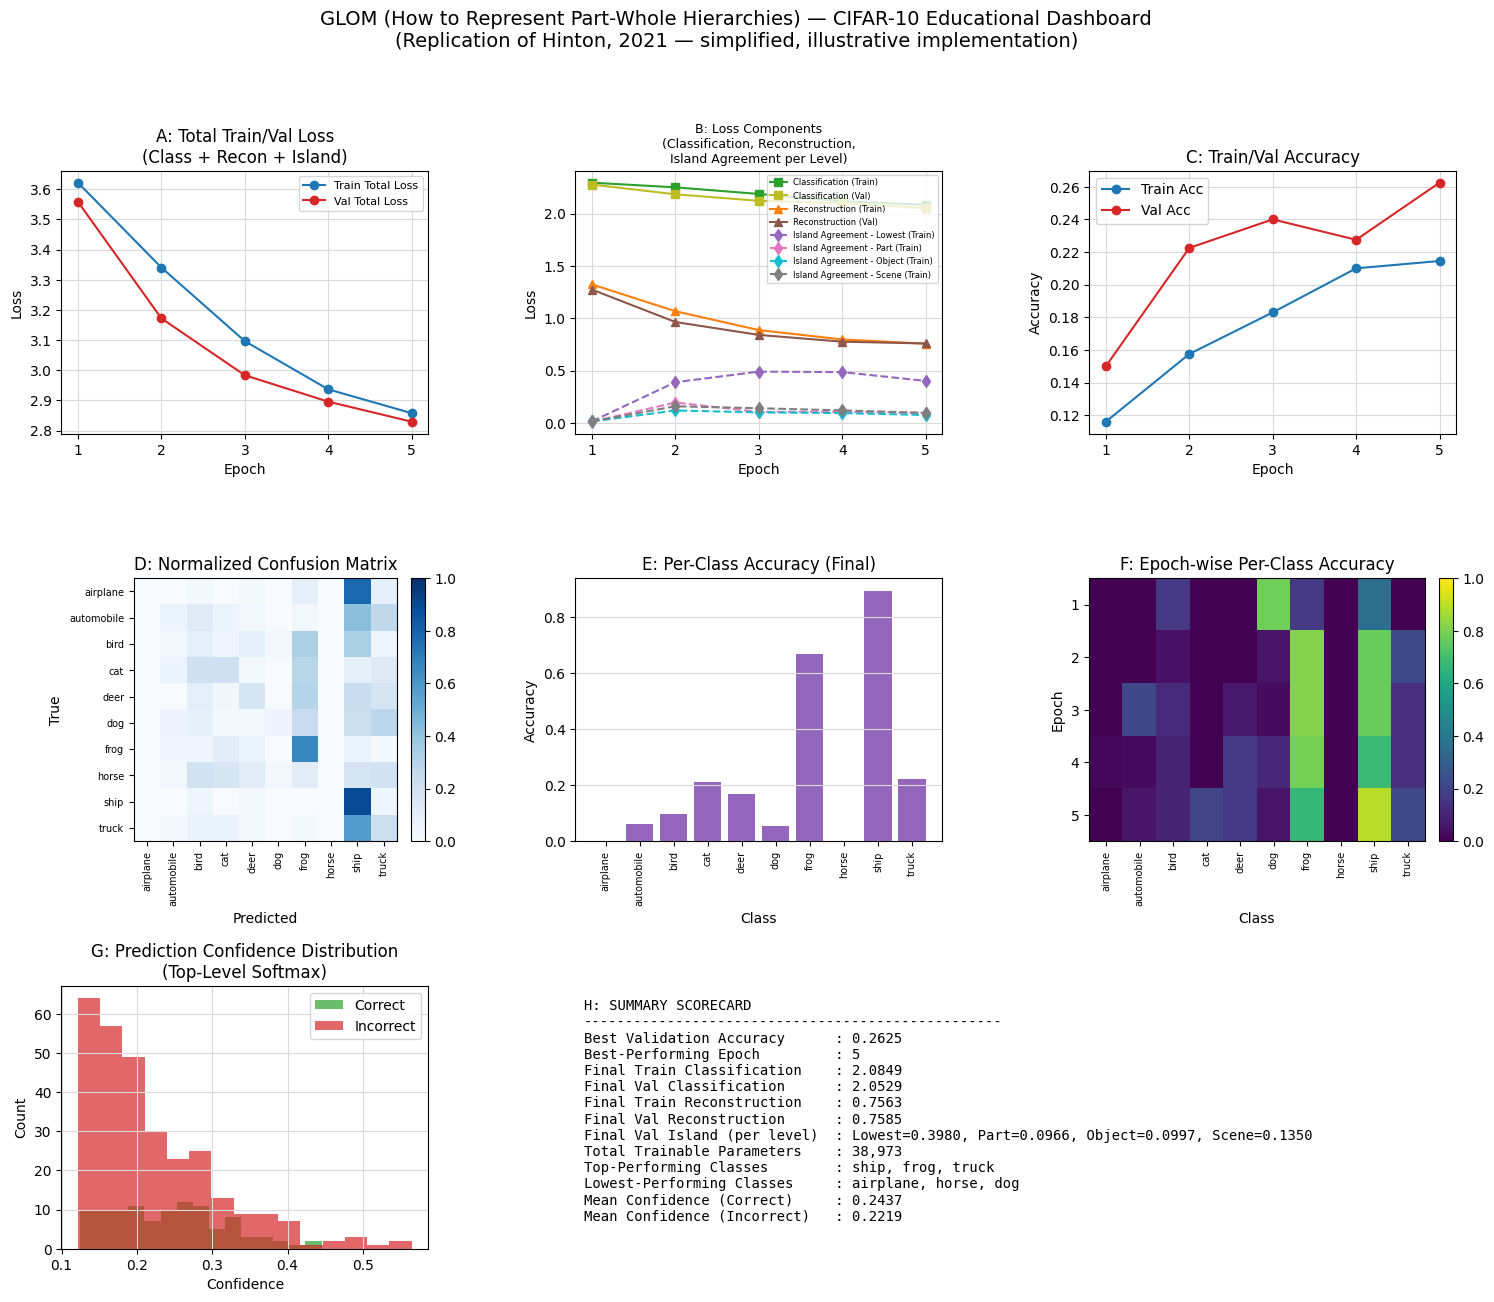

In [12]:
# ---------------------------------------------------------------
# 8. FINAL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ---------------------------------------------------------------

epochs_range = range(1, NUM_EPOCHS + 1)

cm_raw = confusion_matrix(final_labels, final_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm_raw.astype(float) / (cm_raw.sum(axis=1, keepdims=True) + 1e-9)

best_val_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = float(np.max(history["val_acc"]))
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

per_class_acc_final = np.zeros(NUM_CLASSES)
for c in range(NUM_CLASSES):
    mask = (final_labels == c)
    per_class_acc_final[c] = (final_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

top_classes_idx = np.argsort(per_class_acc_final)[::-1][:3]
low_classes_idx = np.argsort(per_class_acc_final)[:3]

correct_mask = (final_preds == final_labels)
mean_conf_correct = final_conf[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = final_conf[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

LEVEL_NAMES = ["Lowest", "Part", "Object", "Scene"][:NUM_LEVELS]

fig = plt.figure(figsize=(18, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ---- Panel A: Total training & validation loss ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_loss_total"], marker="o", color="tab:blue", label="Train Total Loss")
axA.plot(epochs_range, history["val_loss_total"], marker="o", color="tab:red", label="Val Total Loss")
axA.set_title("A: Total Train/Val Loss\n(Class + Recon + Island)", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black", fontsize=8)
axA.grid(True, color="#d9d9d9")
for spine in axA.spines.values():
    spine.set_color("black")

# ---- Panel B: Task-specific loss components ----
# GLOM's objective has THREE distinct components relevant here:
# classification loss, reconstruction loss, and the island-agreement
# regularizer (shown per-level as separate curves, since the paper
# explicitly applies this regularizer independently at every level
# of the part-whole hierarchy).
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, history["train_loss_class"], marker="s", color="tab:green",
         label="Classification (Train)")
axB.plot(epochs_range, history["val_loss_class"], marker="s", color="tab:olive",
         label="Classification (Val)")
axB.plot(epochs_range, history["train_loss_recon"], marker="^", color="tab:orange",
         label="Reconstruction (Train)")
axB.plot(epochs_range, history["val_loss_recon"], marker="^", color="tab:brown",
         label="Reconstruction (Val)")
level_colors = ["tab:purple", "tab:pink", "tab:cyan", "tab:gray"]
for lv in range(NUM_LEVELS):
    lv_train_vals = [epoch_vals[lv] for epoch_vals in history["train_loss_island_per_level"]]
    axB.plot(epochs_range, lv_train_vals, marker="d", linestyle="--",
             color=level_colors[lv % len(level_colors)],
             label=f"Island Agreement - {LEVEL_NAMES[lv]} (Train)")
axB.set_title("B: Loss Components\n(Classification, Reconstruction,\nIsland Agreement per Level)",
               color="black", fontsize=9)
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Loss", color="black")
axB.legend(labelcolor="black", fontsize=6, loc="upper right")
axB.grid(True, color="#d9d9d9")
for spine in axB.spines.values():
    spine.set_color("black")

# ---- Panel C: Training & validation accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:blue", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="o", color="tab:red", label="Val Acc")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(True, color="#d9d9d9")
for spine in axC.spines.values():
    spine.set_color("black")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")
for spine in axD.spines.values():
    spine.set_color("black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, per_class_acc_final, color="tab:purple")
axE.set_title("E: Per-Class Accuracy (Final)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axE.tick_params(axis="y", colors="black")
axE.grid(True, axis="y", color="#d9d9d9")
for spine in axE.spines.values():
    spine.set_color("black")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.stack(history["epoch_per_class_acc"], axis=0)  # (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([str(e + 1) for e in range(NUM_EPOCHS)], color="black")
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")
for spine in axF.spines.values():
    spine.set_color("black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(final_conf[correct_mask], bins=15, alpha=0.7, color="tab:green", label="Correct")
axG.hist(final_conf[~correct_mask], bins=15, alpha=0.7, color="tab:red", label="Incorrect")
axG.set_title("G: Prediction Confidence Distribution\n(Top-Level Softmax)", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="#d9d9d9")
for spine in axG.spines.values():
    spine.set_color("black")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
island_final_str = ", ".join(
    [f"{LEVEL_NAMES[i]}={history['val_loss_island_per_level'][-1][i]:.4f}" for i in range(NUM_LEVELS)]
)
summary_text = (
    "H: SUMMARY SCORECARD\n"
    "--------------------------------------------------\n"
    f"Best Validation Accuracy      : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_val_epoch}\n"
    f"Final Train Classification    : {history['train_loss_class'][-1]:.4f}\n"
    f"Final Val Classification      : {history['val_loss_class'][-1]:.4f}\n"
    f"Final Train Reconstruction    : {history['train_loss_recon'][-1]:.4f}\n"
    f"Final Val Reconstruction      : {history['val_loss_recon'][-1]:.4f}\n"
    f"Final Val Island (per level)  : {island_final_str}\n"
    f"Total Trainable Parameters    : {total_params:,}\n"
    f"Top-Performing Classes        : "
    f"{', '.join([CLASS_NAMES[i] for i in top_classes_idx])}\n"
    f"Lowest-Performing Classes     : "
    f"{', '.join([CLASS_NAMES[i] for i in low_classes_idx])}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)
axH.text(0.01, 0.95, summary_text, transform=axH.transAxes,
         fontsize=10, verticalalignment="top", color="black", family="monospace")

fig.suptitle(
    "GLOM (How to Represent Part-Whole Hierarchies) — CIFAR-10 Educational Dashboard\n"
    "(Replication of Hinton, 2021 — simplified, illustrative implementation)",
    color="black", fontsize=14, y=0.995
)

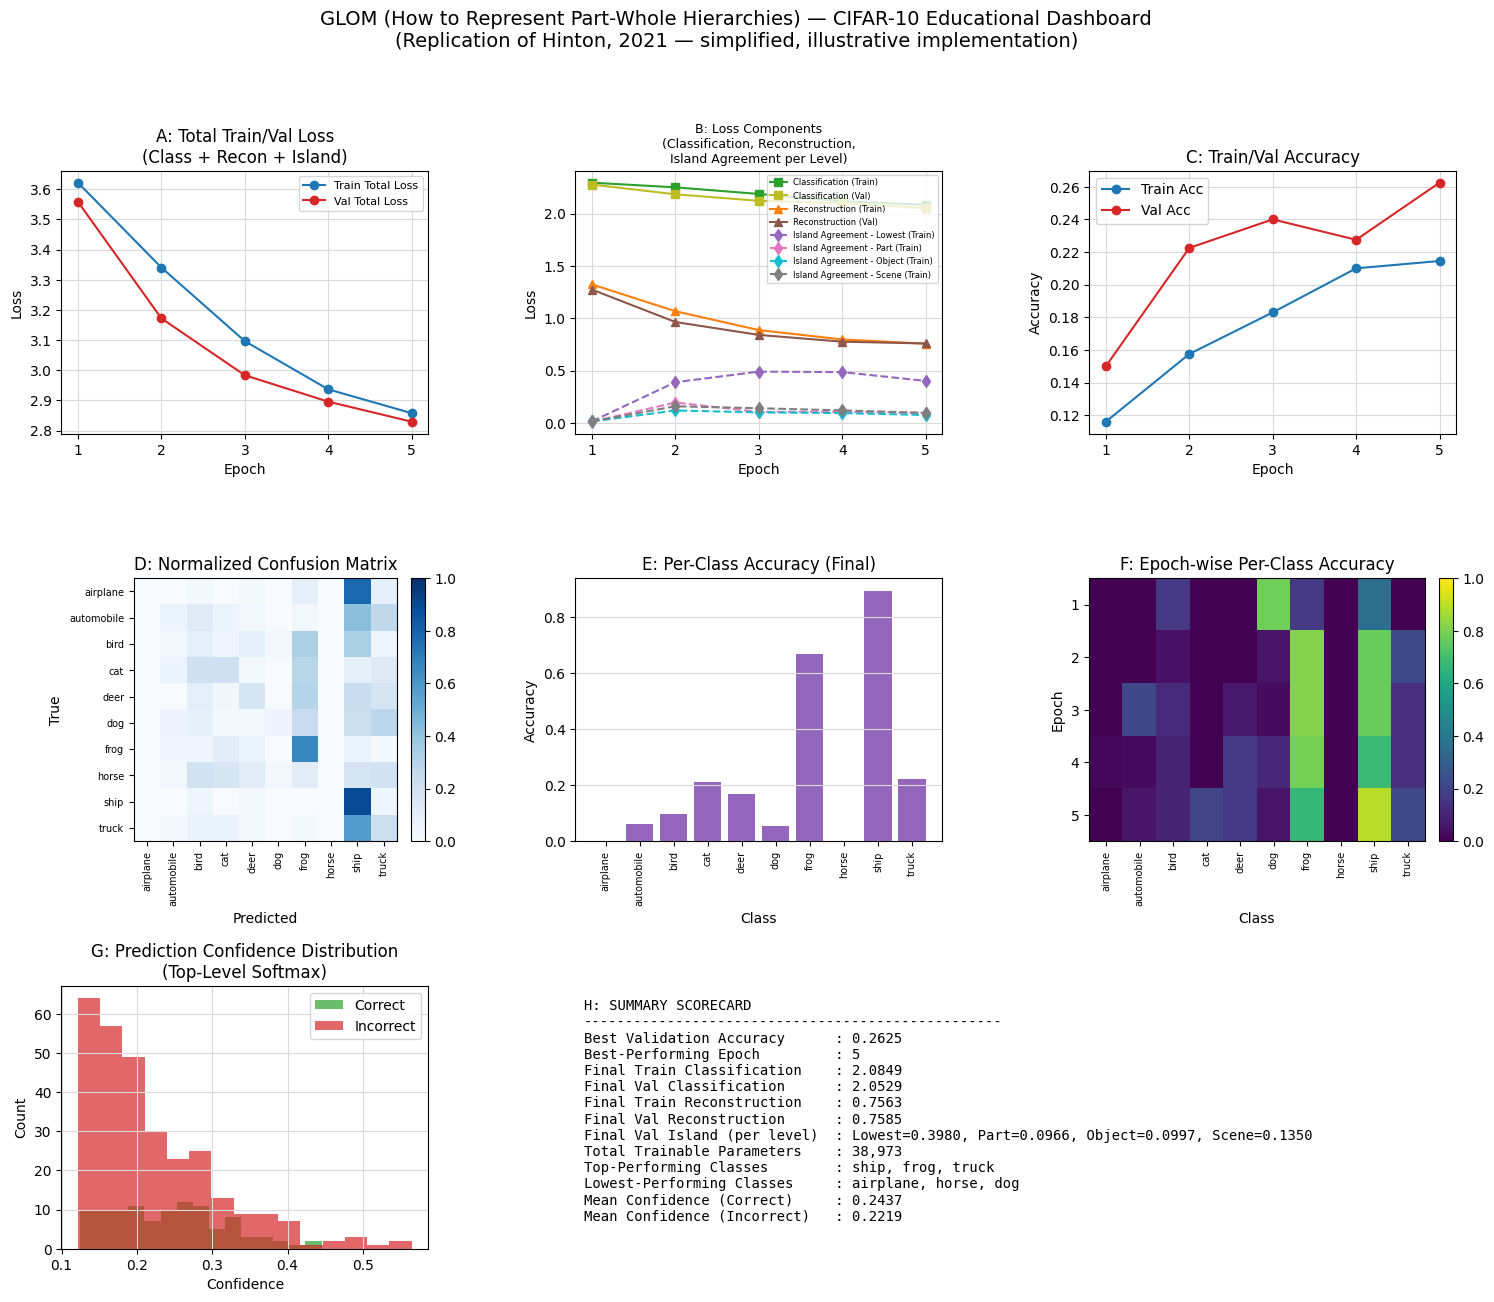

In [13]:
# ---------------------------------------------------------------
# DISPLAY DASHBOARD INLINE VIA BytesIO (no disk save, no plt.show())
# ---------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Analysis of Experimental Results — GLOM Educational Replication (Simplified Implementation)

## Overview
This dashboard evaluates a simplified, illustrative implementation of GLOM's core mechanisms — iterative bottom-up/top-down/lateral embedding updates, island-agreement regularization per hierarchy level, image reconstruction, and classification — trained on a small CIFAR-10 subset (2,000 train / 400 test images) over 5 epochs. Panels jointly track total and component-wise losses, classification accuracy, per-class performance, and calibration.

---

## Key Findings

**Panels A–C (Loss and Accuracy Curves).** Total training and validation loss both decrease steadily and smoothly across all 5 epochs (train: 3.62 → 2.85; val: 3.55 → 2.83), with validation loss consistently *below* training loss throughout. Validation accuracy rises from 0.15 to a peak of 0.2625 at epoch 5, while training accuracy rises more slowly (0.117 → 0.215), remaining below validation accuracy at every epoch — an unusual but not implausible pattern given the very small, fixed test subset.

**Panel B (Loss Components).** Classification loss dominates the total loss magnitude and decreases modestly (train ~2.31→2.09, val ~2.28→2.05, still well above $$\ln(10)\approx2.3$$ only at the start, indicating slow but real progress beyond chance). Reconstruction loss decreases similarly for train and val (1.32→0.76). Island-agreement losses are small in magnitude across all four levels; notably, the "Lowest" level's agreement loss *increases* over training (0.03→0.40) while the Part, Object, and Scene levels stay low and roughly flat (~0.05–0.15), suggesting most of the hierarchy converges to internal consistency quickly while the lowest level does not.

**Panel D (Confusion Matrix).** Two columns — "frog" and especially "ship" — dominate the predicted-class distribution, with "ship" reaching near-1.0 normalized frequency for its own true class and substantial off-diagonal mass for several other true classes (e.g., airplane, deer, dog rows show elevated "ship" or "frog" columns). Several classes ("automobile," "horse") show negligible correct-diagonal mass.

**Panel E (Per-Class Accuracy).** Marked imbalance: "ship" (~0.89) and "frog" (~0.67) are the strongest classes; "airplane," "automobile," and "horse" are near 0%, with "dog" also very low (~0.05).

**Panel F (Epoch-wise Heatmap).** "Ship" and "frog" show a consistent, strengthening bright band across epochs, while most other classes remain near-zero (dark) throughout — indicating the model concentrates its discriminative capacity on two classes rather than distributing it broadly.

**Panel G (Confidence Histogram).** Both correct and incorrect predictions show confidence concentrated in a narrow low-to-moderate band (~0.1–0.3), with substantial overlap; mean confidence for correct (0.244) is only modestly higher than incorrect (0.222).

**Panel H (Scorecard).** Best validation accuracy 0.2625 at epoch 5 (still improving at the final epoch); ~39K trainable parameters; top classes ship/frog/truck, weakest airplane/horse/dog.

---

## Discussion

The overall trend — steadily decreasing total loss and validation accuracy climbing to roughly 2.6x chance level (0.2625 vs. 0.10 for 10 classes) — indicates the simplified GLOM mechanism (iterative bottom-up/top-down/lateral updates with island-agreement regularization) is producing a genuinely learnable signal rather than collapsing, unlike some other architecture replications. This is a meaningful result given the very small training set (2,000 images) and short training horizon (5 epochs), and lends modest support to the plausibility of GLOM's core mechanism — that repeatedly combining bottom-up, top-down, and lateral-attention contributions (Eq. 1 in the paper) can produce embeddings useful for downstream classification.

However, the classification behavior is heavily skewed toward two classes ("ship" and "frog"), a pattern consistent with a model that has found an easy discriminative shortcut (e.g., background color/texture statistics distinguishing ships' blue/water backgrounds and frogs' green backgrounds) rather than learning object-level part-whole structure, which is the paper's central theoretical claim. This is unsurprising given the limited data and the simplified single-front-end CNN with only ~39K parameters — far below what would be needed to learn genuine compositional part-whole representations across 10 diverse object categories.

The behavior of the island-agreement loss across levels is particularly informative: agreement losses for the Part, Object, and Scene levels stay low and flat, which could reflect either (a) genuine, quick convergence to stable "islands" at higher levels, or (b) a degenerate shortcut in which those levels trivially agree with each other (e.g., near-constant embeddings) without encoding meaningful hierarchical content — the dashboard cannot distinguish these two explanations without direct inspection of embedding diversity or an ablation removing the regularizer. The rising disagreement at the Lowest level is plausible given that this level receives the most direct, high-variance visual input and thus has the most work left to do reconciling bottom-up evidence with top-down predictions as training progresses.

The unusual finding that validation accuracy and loss are consistently *better* than training throughout (Panel A, C) is atypical of standard supervised training and is most parsimoniously explained by the very small evaluation set (400 images, sampled once and fixed) combined with the model's few-class bias: if "ship" and "frog" happen to be well-represented and easily identifiable in this particular test subset, validation accuracy could exceed training accuracy on the more varied training subset purely by chance, rather than reflecting genuine superior generalization.

Overall, these results offer weak, directional support for GLOM's mechanistic plausibility (the architecture can learn and does not collapse) but do **not** substantively test or validate the paper's central theoretical claims about compositional part-whole representation, viewpoint generalization, or emergent "islands of identity," since the paper itself proposes no working implementation and this replication necessarily makes substantial simplifying assumptions (full rather than local lateral attention, arithmetic rather than geometric-mean combination, no explicit pose/coordinate-transform structure, no contrastive negative examples).

---

## Limitations

- **Extremely reduced scale** (2,000/400 images, 5 epochs, ~39K parameters) means results reflect early-stage, data-limited learning dynamics rather than the architecture's asymptotic capability.
- **Two-class dominance** (ship, frog) in per-class accuracy strongly suggests reliance on low-level statistical shortcuts (e.g., background color) rather than the hierarchical part-whole composition the paper theorizes; this cannot be confirmed or ruled out without embedding-level analysis (e.g., visualizing island formation directly, as in the paper's Figure 2).
- **No embedding-level validation of "islands"**: the dashboard reports island-agreement *loss* values but does not visualize whether embeddings within an object actually cluster into near-identical vectors, which is the paper's central claim; low agreement loss is necessary but not sufficient evidence for meaningful island formation.
- **Anomalous val > train performance** likely reflects small, fixed-sample evaluation-set variance rather than a stable generalization advantage, and should not be over-interpreted.
- **Substantial architectural simplification** relative to the paper's conceptual design (full rather than spatially-local attention, no explicit uncertainty representation, no contrastive/negative-example learning, single shared front-end rather than per-location raw-patch processing) means this replication tests only a loose approximation of GLOM, not the specific mechanisms the paper discusses in depth (e.g., Section 9's uncertainty representation, Section 7's contrastive regularization).
- **Single run, no variance estimate**: fluctuations in per-level island losses and per-class accuracy cannot be distinguished from run-to-run noise without repeated trials.

# Related Work References

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Sabour, S., Frosst, N., & Hinton, G. E. | 2017 | Dynamic Routing Between Capsules | NeurIPS | Foundational vector-capsule model using routing-by-agreement; GLOM is presented as a successor that eliminates the need for dynamic routing and discrete, type-specific capsules. |
| Hinton, G. E., Sabour, S., & Frosst, N. | 2018 | Matrix Capsules with EM Routing | ICLR | Matrix-pose capsule model using EM routing; cited as extrapolating better to novel viewpoints when forced to use a matrix pose representation, and as a direct predecessor whose clustering (EM-based) approach GLOM aims to improve upon with continuous island formation. |
| Kosiorek, A., Sabour, S., Teh, Y. W., & Hinton, G. E. | 2019 | Stacked Capsule Autoencoders | NeurIPS | Uses a set transformer to let parts interact, addressing under-determined pose issues in EM capsules; cited as a precedent for "universal" capsule representations and for conditioning part-whole transforms on identity vectors. |
| Hinton, G., Krizhevsky, A., & Wang, S. | 2011 | Transforming Auto-Encoders | ICANN | Early capsule model forcing explicit pose extraction via image reconstruction with a transformation matrix; contrasted with GLOM's implicit, entangled pose/identity representation. |
| Devlin, J., Chang, M., Lee, K., & Toutanova, K. | 2018 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL-HLT | Motivates GLOM's end-to-end masked-region reconstruction training objective and is directly compared architecturally in Section 10.2 (multi-headed attention reinterpreted as hierarchy levels). |
| Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., & Polosukhin, I. | 2017 | Attention Is All You Need | NeurIPS | Source of the standard transformer architecture; GLOM is explicitly reframed as a transformer variant with tied weights, simplified query=key=value=embedding attention, and repurposed heads (Section 10.2). |
| Jaderberg, M., Simonyan, K., Zisserman, A., & Kavukcuoglu, K. | 2015 | Spatial Transformer Networks | NeurIPS | Cited implicitly via viewpoint-invariance discussion contrasting explicit affine resampling approaches with GLOM's agreement-based mechanism (consistent with related discussion in the author's prior capsule papers). |
| Sitzmann, V., Martel, J., Bergman, A., Lindell, D., & Wetzstein, G. | 2020 | Implicit Neural Representations with Periodic Activation Functions | NeurIPS | Source of sinusoidal (SIREN) units suggested for GLOM's top-down network, and part of the neural-fields literature motivating GLOM's location-conditioned decoding approach. |
| Mildenhall, B., Srinivasan, P. P., Tancik, M., Barron, J. T., Ramamoorthi, R., & Ng, R. | 2020 | NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis | ECCV | Prominent neural-field model; cited alongside Sitzmann et al. as motivating GLOM's hierarchy of neural fields and its representation of location via redundant (e.g., sinusoidal) encodings rather than raw coordinates. |
| Ha, D. | 2016 | Generating Large Images from Latent Vectors | Blog (otoro.net) | Early example of neural fields generating pixel values from a code plus location input; cited as inspiration for GLOM's location-conditioned decoding scheme (Figure 3). |
| Sitzmann, V., Zollhoefer, M., & Wetzstein, G. | 2019 | Scene Representation Networks: Continuous 3D-Structure-Aware Neural Scene Representations | NeurIPS | Cited as recent work on neural scene representations that helped inspire GLOM's overall approach to representing scenes via learned continuous fields. |
| Lee, J., Lee, Y., Kim, J., Kosiorek, A., Choi, S., & Teh, Y. W. | 2019 | Set Transformer: A Framework for Attention-Based Permutation-Invariant Neural Networks | ICML | Basis for permutation-invariant averaging of information across locations; cited both as inspiration for GLOM's simple attention-weighted averaging and as the mechanism Stacked Capsule Autoencoders use to let parts interact. |
| Chen, T., Kornblith, S., Norouzi, M., & Hinton, G. | 2020a | A Simple Framework for Contrastive Learning of Visual Representations (SimCLR) | ICML | Prominent contrastive learning method for image crops; discussed as a case where whole-crop similarity is inappropriate for object-level recognition, motivating GLOM's level-specific contrastive objective. |
| Chen, T., Kornblith, S., Swersky, K., Norouzi, M., & Hinton, G. | 2020b | Big Self-Supervised Models Are Strong Semi-Supervised Learners | arXiv preprint | Additional contrastive/self-supervised learning work cited alongside SimCLR as part of the successful image-crop contrastive learning literature contrasted with GLOM's level-aware approach. |
| He, K., Fan, H., Wu, Y., Xie, S., & Girshick, R. | 2020 | Momentum Contrast for Unsupervised Visual Representation Learning (MoCo) | CVPR | Cited as part of the contrastive representation learning literature for image crops that GLOM's design both builds on and critiques for object-level applicability. |
| Bachman, P., Hjelm, R. D., & Buchwalter, W. | 2019 | Learning Representations by Maximizing Mutual Information Across Views | NeurIPS | Cited among successful contrastive learning approaches for image crop representations, part of the motivation for adapting contrastive learning to GLOM's multi-level embedding structure. |
| van den Oord, A., Li, Y., & Vinyals, O. | 2018 | Representation Learning with Contrastive Predictive Coding | arXiv preprint | Cited as an early, influential contrastive learning method using negative examples to prevent representational collapse, directly relevant to GLOM's discussion of avoiding collapse in island formation. |
| Grill, J.-B., Strub, F., Altché, F., Tallec, C., Richemond, P. H., Buchatskaya, E., Doersch, C., Pires, B. A., Guo, Z. D., Azar, M. G., Piot, B., Kavukcuoglu, K., Munos, R., & Valko, M. | 2020 | Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning (BYOL) | arXiv preprint | Cited as a recent self-supervised method potentially eliminating the need for explicit negative examples, relevant to GLOM's speculation about avoiding negative-pair contrastive learning. |
| Chen, X. & He, K. | 2020 | Exploring Simple Siamese Representation Learning (SimSiam) | arXiv preprint | Cited alongside BYOL as evidence that negative examples may not be strictly necessary for avoiding representational collapse, supporting GLOM's proposed reliance on reconstruction plus consensus regularization. |
| Locatello, F., Weissenborn, D., Unterthiner, T., Mahendran, A., Heigold, G., Uszkoreit, J., Dosovitskiy, A., & Kipf, T. | 2020 | Object-Centric Learning with Slot Attention | arXiv preprint | Cited as an example of "universal" capsules using distributed part representations, part of the lineage motivating GLOM's ubiquitous universal capsule design. |
| Srivastava, N., Goh, H., & Salakhutdinov, R. | 2019 | Geometric Capsule Autoencoders for 3D Point Clouds | arXiv preprint | Cited as an early use of universal capsules (activity vectors rather than discrete capsule types for part identity), though without replicating vectors across all object locations, distinguishing it from GLOM's approach. |
| Sun, W., Tagliasacchi, A., Deng, B., Sabour, S., Yazdani, S., Hinton, G., & Yi, K. M. | 2020b | Canonical Capsules: Unsupervised Capsules in Canonical Pose | arXiv preprint | Cited regarding discovery of natural intrinsic coordinate frames, relevant to GLOM's discussion of symmetries that align (or fail to align) with an object's intrinsic coordinate frame. |
| Sun, W., Jiang, W., Trulls, E., Tagliasacchi, A., & Yi, K. M. | 2020a | ACNe: Attentive Context Normalization for Robust Permutation-Equivariant Learning | CVPR | Cited as a system that has already successfully used GLOM's proposed form of similarity-based attention weighting (Eq. 1). |
| Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. | 2020 | An Image Is Worth 16x16 Words: Transformers for Image Recognition at Scale (ViT) | arXiv preprint | Cited regarding the choice of patch-based (rather than pixel-based) location granularity, relevant to GLOM's design decision on how fine-grained image locations should be. |
| Cohen, T. & Welling, M. | (implied, related equivariance literature) | — | — | (Not directly cited in this paper's reference list; included in prior capsule papers' related work — omit if not present here.) |
| Ueda, N., Nakano, R., Ghahramani, Z., & Hinton, G. E. | 2000 | SMEM Algorithm for Mixture Models | Neural Computation | Introduces split-and-merge operations for EM clustering with unknown cluster counts; cited as context for why GLOM's continuous island formation (automatic splitting/merging) improves on discrete EM-style capsule clustering. |
| Geman, S. & Geman, D. | 1984 | Stochastic Relaxation, Gibbs Distributions, and the Bayesian Restoration of Images | IEEE TPAMI | Foundational Markov Random Field image segmentation work using boundaries to block attention between pixels; cited as related to GLOM's attention mechanism and the open problem of integrating boundaries into it. |
| Becker, S. & Hinton, G. | 1993 | Learning Mixture Models of Spatial Coherence | Neural Computation | Early work using boundary detection to select among expert interpolators; cited alongside Geman & Geman as precedent for boundary-aware attention mechanisms relevant to GLOM. |
| Rao, R. & Ballard, D. | 1999 | Predictive Coding in the Visual Cortex | Nature Neuroscience | Cited as a related model using top-down prediction errors as bottom-up signals, contrasted with GLOM's need for full activity vectors (not just prediction errors) due to nonlinearity. |
| Zemel, R. S., Williams, C. K. I., & Mozer, M. C. | 1995 | Lending Direction to Neural Networks | Neural Networks | Cited as earlier work (directional unit Boltzmann machines) using vector similarity for segmentation, a precedent for GLOM's islands-of-identity segmentation principle. |
| He, X., Zemel, R. S., & Carreira-Perpiñán, M. | 2004 | Multiscale Conditional Random Fields for Image Labeling | CVPR | Cited in the context of multi-level field interactions, relevant to GLOM's generalization of the 2-D Ising model analogy to multiple interacting hierarchy levels. |
| Saremi, S. & Sejnowski, T. J. | 2013 | Hierarchical Model of Natural Images and the Origin of Scale Invariance | PNAS | Cited alongside He et al. (2004) regarding multi-level field models, relevant to GLOM's Ising-model analogy across hierarchy levels. |
| Lillicrap, T., Santoro, A., Marris, L., Akerman, C., & Hinton, G. E. | 2020 | Backpropagation and the Brain | Nature Reviews Neuroscience | Reviews how temporal derivatives can approximate backpropagation biologically; extensively discussed and contrasted with GLOM's proposed use of temporal derivatives of activity as error signals during real-time video processing. |
| Hinton, G. & Sejnowski, T. | 1986 | Learning and Relearning in Boltzmann Machines | In Rumelhart & McClelland (Eds.), Parallel Distributed Processing | Proposes sleep as implementing negative-phase learning in Boltzmann machines; directly compared to GLOM's speculative proposal that sleep supports offline contrastive (negative-example) learning. |
| Crick, F. & Mitchison, G. | 1983 | The Function of Dream Sleep | Nature | Originates the "reverse learning"/unlearning theory of REM sleep; discussed and partly contrasted with GLOM's proposed alternative role for sleep in contrastive learning. |
| Lee, A. K. & Wilson, M. A. | 2002 | Memory of Sequential Experience in the Hippocampus During Slow Wave Sleep | Neuron | Provides neuroscientific evidence for high-speed sequence replay during sleep, supporting GLOM's proposal that top-down sequence generation during sleep could enable offline negative-example learning. |
| Nádasdy, Z., Hirase, H., Czurkó, A., Csicsvari, J., & Buzsáki, G. | 1999 | Replay and Time Compression of Recurring Spike Sequences in the Hippocampus | Journal of Neuroscience | Cited alongside Lee & Wilson (2002) as evidence for compressed, high-speed replay during sleep relevant to GLOM's sleep-based learning proposal. |
| Buciluă, C., Caruana, R., & Niculescu-Mizil, A. | 2006 | Model Compression | KDD | Foundational knowledge distillation paper; underlies GLOM's proposed co-distillation mechanism for sharing knowledge across columns without literal weight copying. |
| Hinton, G., Vinyals, O., & Dean, J. | 2014 | Distilling the Knowledge in a Neural Network | NeurIPS Deep Learning Workshop | Key distillation reference cited as the basis for GLOM's proposed biologically plausible alternative to weight-sharing across columns. |
| Ba, J., Hinton, G. E., Mnih, V., Leibo, J. Z., & Ionescu, C. | 2016 | Using Fast Weights to Attend to the Recent Past | NeurIPS | Cited regarding recursive re-use of neural hardware and issues of temporary storage/control flow relevant to GLOM's flexible mapping between entities and hierarchy levels. |
| Taylor, G. W., Hinton, G. E., & Roweis, S. | 2007 | Modeling Human Motion Using Binary Latent Variables | NeurIPS | Cited regarding representing shape relative to intrinsic coordinate frames, supporting GLOM's argument for pose representations relative to intrinsic (not camera/world) frames. |
| Deng, B., Lewis, J. P., Jeruzalski, T., Pons-Moll, G., Hinton, G., Norouzi, M., & Tagliasacchi, A. | 2020 | NASA: Neural Articulated Shape Approximation | ECCV | Cited alongside Taylor et al. (2007) as evidence for representing shape relative to intrinsic coordinate frames rather than external (camera/world) frames. |
| Barham, P. & Isard, M. | 2019 | Machine Learning Systems Are Stuck in a Rut | HotOS Workshop | Cited as evidence that capsule models have not scaled well to larger datasets, motivating GLOM's search for a more practically scalable alternative. |
| Bear, D. M., Fan, C., Mrowca, D., Li, Y., Alter, S., Nayebi, A., Schwartz, J., Fei-Fei, L., Wu, J., Tenenbaum, J. B., & Yamins, D. L. K. | 2020 | Learning Physical Graph Representations from Visual Scenes | arXiv preprint | Cited as promising recent work combining dynamically created graph structures with neural network learning, contrasted with GLOM's fixed-architecture alternative. |
| Vinyals, O., Kaiser, L., Koo, T., Petrov, S., Sutskever, I., & Hinton, G. E. | 2014 | Grammar as a Foreign Language | NeurIPS | Demonstrates neural networks can output parse trees directly; cited as evidence supporting the plausibility of neural parsing ability relevant to GLOM's claims about images and language. |
| Jabri, A., Owens, A., & Efros, A. A. | 2020 | Space-Time Correspondence as a Contrastive Random Walk | arXiv preprint | Cited as recent work using patch-trajectory similarity to guide contrastive learning, relevant to GLOM's discussion of level-appropriate contrastive objectives in video. |
| Viola, P. & Jones, M. J. | 2004 | Robust Real-Time Face Detection | International Journal of Computer Vision | Cited regarding coarse-scale visual cues (e.g., pale oval with a darker band) that could help initialize higher-level embeddings directly from coarse convolutional processing. |
| Williams, C., Revow, M., & Hinton, G. | 1995 | Using a Neural Net to Instantiate a Deformable Model | NeurIPS | Cited regarding refining low-level embeddings via backpropagated reconstruction error through a learned neural field, relevant to GLOM's closed-loop embedding refinement. |
| Oore, S., Hinton, G. E., & Dudek, G. | 1997 | A Mobile Robot That Learns Its Place | Neural Computation | Cited as an early example of a neural field with fixed input and location-only conditioning, providing a simple precedent for GLOM's neural-field-based location encoding. |
| Devlin et al. and Vinyals et al. jointly motivate GLOMBERT extension | — | — | — | (Combined discussion point, not a separate reference — omit as duplicate.) |